# Cancer Mutation Classification - Modular Analysis


In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

sys.path.append(os.path.abspath('..'))

from src.data_loader import load_clean_data
from src.features import FeatureEngineer
from src.training import train_pipeline
from src.evaluation import evaluate_medical_utility, plot_visual_assessment
from src.config import RANDOM_STATE, TEST_SIZE

from src.gpu_setup import setup_gpu
setup_gpu()

I0000 00:00:1776970467.813824   14827 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776970467.862654   14827 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776970469.238961   14827 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


✅ GPU Mode Active: 1 Physical GPUs, 1 Logical GPUs configured.


I0000 00:00:1776970469.620659   14827 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2285 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


## 1. Data Procurement
Loading high-confidence variants (2-4 stars) from the ClinVar summary.

In [2]:
df = load_clean_data(row_limit=1000000)

train_df, test_df = train_test_split(
    df, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE, 
    stratify=df['ClinSigSimple']
)

print(f"Training set: {len(train_df)} variants")
print(f"Test set: {len(test_df)} variants")

Dataset successfully loaded. Final size: 600033 variants.
Training set: 510028 variants
Test set: 90005 variants


## 2. Feature Engineering & Preparation
Extracting biological features (Ti/Tv ratio) and gene-level statistics.

In [3]:
engineer = FeatureEngineer()
X_train = engineer.fit_transform(train_df)
X_test = engineer.transform(test_df)

y_train = train_df['ClinSigSimple'].values
y_test = test_df['ClinSigSimple'].values

## 3. Neural Architecture & Training
The model utilizes a Focal Loss function to maintain high detection rates for rare pathogenic variants.

In [4]:
model, history = train_pipeline(X_train, y_train, engineer)

Epoch 1/100


I0000 00:00:1776970806.302727   14912 service.cc:153] XLA service 0x3b9c8490 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776970806.302752   14912 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6 (Driver: 12.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1776970806.354492   14912 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776970806.667080   14912 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1776970806.730685   14912 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3959__.34
I0000 00:00:1776970808.094276   15424 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_16', 24 bytes spill stores, 24 bytes spill loads

I0000 00:00:1776970809.116510   15420 subprocess_compilation.cc:348] pt

 27/212 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9375 - loss: 0.0282 - precision: 0.2981 - recall: 0.3395

I0000 00:00:1776970817.970452   14912 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


208/212 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9629 - loss: 0.0156 - precision: 0.5561 - recall: 0.4160

I0000 00:00:1776970819.619763   14909 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3959__.34
I0000 00:00:1776970820.394818   15658 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_38', 600 bytes spill stores, 600 bytes spill loads

I0000 00:00:1776970820.711422   15645 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_26', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776970820.836321   15659 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_26', 84 bytes spill stores, 84 bytes spill loads

I0000 00:00:1776970821.335731   15659 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_24', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776970821.673228   15646 subprocess_compilat

212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9630 - loss: 0.0156 - precision: 0.5584 - recall: 0.4172

I0000 00:00:1776970831.885593   15885 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_16', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776970832.430545   15884 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_14', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776970833.393929   15878 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_12', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776970833.702479   15881 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_12', 8860 bytes spill stores, 8880 bytes spill loads



212/212 ━━━━━━━━━━━━━━━━━━━━ 30s 79ms/step - accuracy: 0.9713 - loss: 0.0117 - precision: 0.6796 - recall: 0.4802 - val_accuracy: 0.9659 - val_loss: 0.0136 - val_precision: 0.9789 - val_recall: 0.1251 - learning_rate: 0.0010
Epoch 2/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9764 - loss: 0.0093 - precision: 0.7725 - recall: 0.5471 - val_accuracy: 0.9767 - val_loss: 0.0096 - val_precision: 0.8227 - val_recall: 0.5101 - learning_rate: 0.0010
Epoch 3/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9770 - loss: 0.0089 - precision: 0.7796 - recall: 0.5585 - val_accuracy: 0.9776 - val_loss: 0.0089 - val_precision: 0.7870 - val_recall: 0.5814 - learning_rate: 0.0010
Epoch 4/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9774 - loss: 0.0087 - precision: 0.7851 - recall: 0.5660 - val_accuracy: 0.9778 - val_loss: 0.0089 - val_precision: 0.7848 - val_recall: 0.5921 - learning_rate: 0.0010
Epoch 5/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.977

## 4. Medical Utility Assessment

2813/2813 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step

--- Clinical Performance Appraisal (Threshold: 0.3292) ---
              precision    recall  f1-score   support

           0       0.99      0.95      0.97     86539
           1       0.39      0.85      0.54      3466

    accuracy                           0.94     90005
   macro avg       0.69      0.90      0.75     90005
weighted avg       0.97      0.94      0.95     90005



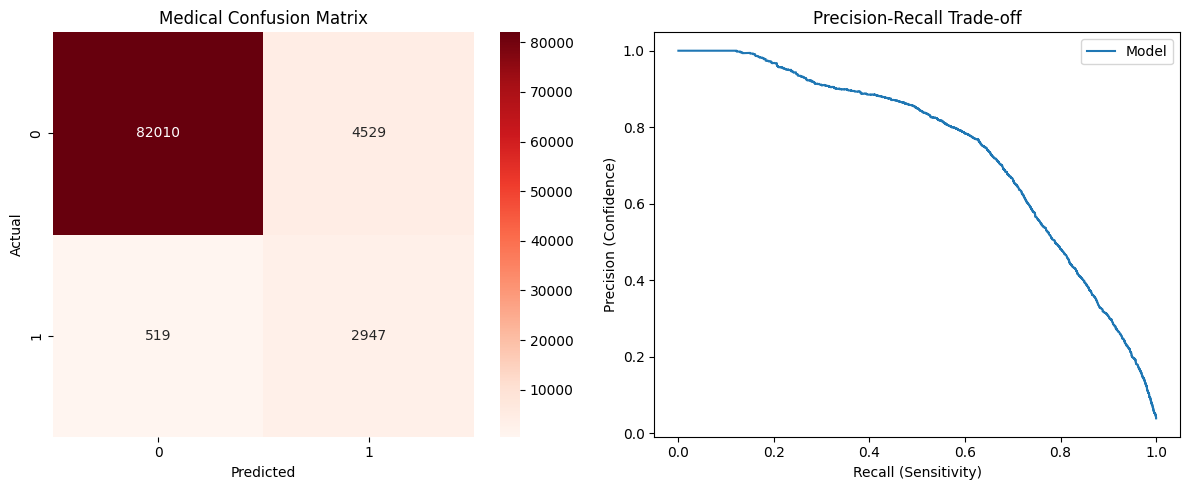

In [7]:
y_pred, y_probs, threshold = evaluate_medical_utility(model, X_test, y_test)
plot_visual_assessment(y_test, y_pred, y_probs)

## 5. Interactive Clinical Inference & Interpretation
This section allows biologists to test the model with individual mutations and receive a human-readable clinical report instead of raw metrics.

In [8]:
from src.evaluation import report_inference

# --- INTERACTIVE TEST AREA ---
# You can change these values to test any mutation.
# The example below is the BRAF V600E mutation (Common in Melanoma).

test_variant = {
    'GeneID': 673,                # Gene ID (e.g., BRAF=673, BRCA1=672)
    'PositionVCF': 140753336,     # Genomic Position (VCF format)
    'ReferenceAlleleVCF': 'A',    # Reference Base
    'AlternateAlleleVCF': 'T',    # Mutant Base
    'Type': 'snp',                # Variant Type (snp, del, ins, etc.)
    'Chromosome': '7'
}

report_inference(model, engineer, test_variant, threshold)


      CANCER MUTATION CLINICAL REPORT
VARIANT: Gene 673 | Pos: 140753336
DNA CHANGE: A -> T
--------------------------------------------------
FINAL CLASSIFICATION: BENIGN (HARMLESS)
CONFIDENCE SCORE: 11.9%
RISK LEVEL: LOW
--------------------------------------------------
BIOLOGICAL CONTEXT:
 - Gene Profile: This gene has a 5.9% historical pathogenicity rate.
 - Mutation Type: snp (Transversion)

CLINICAL ADVICE:
 [ok] Likely a common variation or harmless passenger mutation.
